# Proyek Klasifikasi Gambar: [Hewan]
- **Nama:** [Desti Nur Irawati]
- **Email:** [11221033@student.itk.ac.id]
- **ID Dicoding:** [desssti06]

In [ ]:
!pip install tensorflow

## Import Semua Packages/Library yang Digunakan

In [10]:
!pip install tensorflow
import zipfile, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow.keras.layers import Input
from keras.models import Sequential
from keras.regularizers import l2
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from sklearn.metrics import confusion_matrix
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Data Preparation

In [11]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("nicopalv/dataset-klasifikasi-gambar-hewan")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/dataset-klasifikasi-gambar-hewan


In [12]:
import os
base_dir = '/root/.cache/kagglehub/datasets/nicopalv/dataset-klasifikasi-gambar-hewan/versions/1/dataset/training_set'
os.listdir(base_dir)

['tigers', 'cats', 'dogs']

### Data Loading

In [13]:
import os

print('Image kucing     :', len(os.listdir('/root/.cache/kagglehub/datasets/nicopalv/dataset-klasifikasi-gambar-hewan/versions/1/dataset/training_set/cats')))
print('Image anjing     :', len(os.listdir('/root/.cache/kagglehub/datasets/nicopalv/dataset-klasifikasi-gambar-hewan/versions/1/dataset/training_set/tigers')))
print('Image kelinci    :', len(os.listdir('/root/.cache/kagglehub/datasets/nicopalv/dataset-klasifikasi-gambar-hewan/versions/1/dataset/training_set/dogs')))


Image kucing     : 4000
Image anjing     : 4000
Image kelinci    : 4000


#### Split Dataset

In [14]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

# Path to your dataset directory
base_dir = '/root/.cache/kagglehub/datasets/nicopalv/dataset-klasifikasi-gambar-hewan/versions/1/dataset/training_set'

# Assuming you have subdirectories inside dataset_dir for different classes
classes = os.listdir(base_dir)
class_indices = {class_name: i for i, class_name in enumerate(classes)}

# Collecting file paths and corresponding labels
file_paths = []
labels = []
for class_name in classes:
    class_dir = os.path.join(base_dir, class_name)
    class_files = [os.path.join(class_dir, file) for file in os.listdir(class_dir)]
    file_paths.extend(class_files)
    labels.extend([class_indices[class_name]] * len(class_files))

# Convert to numpy arrays
file_paths = np.array(file_paths)
labels = np.array(labels)

# Split into train and temp (temp will be split into val and test)
train_files, temp_files, train_labels, temp_labels = train_test_split(
    file_paths, labels, test_size=0.3, random_state=42  # 70% train, 30% temp
)

# Split temp into validation and test sets (50% val, 50% test of the 30%)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.5, random_state=42  # 15% val, 15% test
)

# Output sizes
print("Number of training samples:", len(train_files))
print("Number of validation samples:", len(val_files))
print("Number of test samples:", len(test_files))

Number of training samples: 8400
Number of validation samples: 1800
Number of test samples: 1800


In [15]:
import shutil
import os

# Folder tujuan
target_root = "/root/dataset_split"

# Fungsi untuk memindahkan file ke folder yang sesuai
def copy_files(files, labels, subset):
    for file_path, label in zip(files, labels):
        # Dapatkan nama kelas dari label
        class_name = list(class_indices.keys())[list(class_indices.values()).index(label)]
        dest_dir = os.path.join(target_root, subset, class_name)
        os.makedirs(dest_dir, exist_ok=True)  # buat folder jika belum ada
        dest_file_path = os.path.join(dest_dir, os.path.basename(file_path))
        shutil.copy(file_path, dest_file_path)

# Copy file ke masing-masing subset
copy_files(train_files, train_labels, "train")
copy_files(val_files, val_labels, "val")        # <--- tambahan untuk validation set
copy_files(test_files, test_labels, "test")

print("\n✅ Semua file sudah dipindahkan ke:")
print("-", os.path.join(target_root, "train"))
print("-", os.path.join(target_root, "val"))
print("-", os.path.join(target_root, "test"))



✅ Semua file sudah dipindahkan ke:
- /root/dataset_split/train
- /root/dataset_split/val
- /root/dataset_split/test


In [16]:
# Direktori awal untuk train dan test
train_dir = "/root/dataset_split/train"
test_dir = "/root/dataset_split/test"

# Direktori baru untuk dataset gabungan
combined_dir = "/root/animal/dataset"

In [17]:
import os
import shutil

def safe_copy(src, dst):
    if not os.path.exists(dst):
        os.makedirs(dst)
    for item in os.listdir(src):
        src_path = os.path.join(src, item)
        dst_path = os.path.join(dst, item)
        if os.path.isdir(src_path):
            shutil.copytree(src_path, dst_path, dirs_exist_ok=True)
        else:
            shutil.copy2(src_path, dst_path)

image data generator

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset = 'training'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset = 'validation'
)


Found 6721 images belonging to 3 classes.
Found 360 images belonging to 3 classes.


Dataset Checking

Kelas: tigers


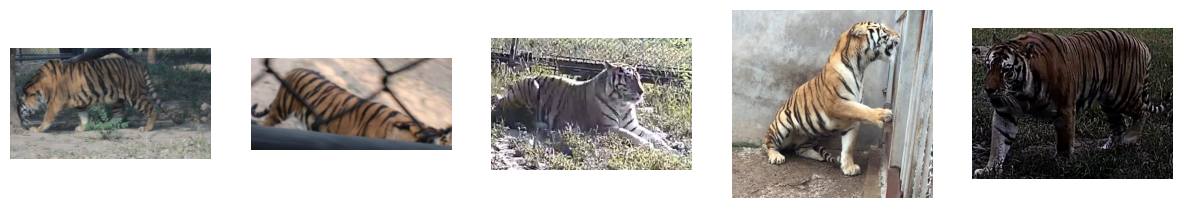



Kelas: cats


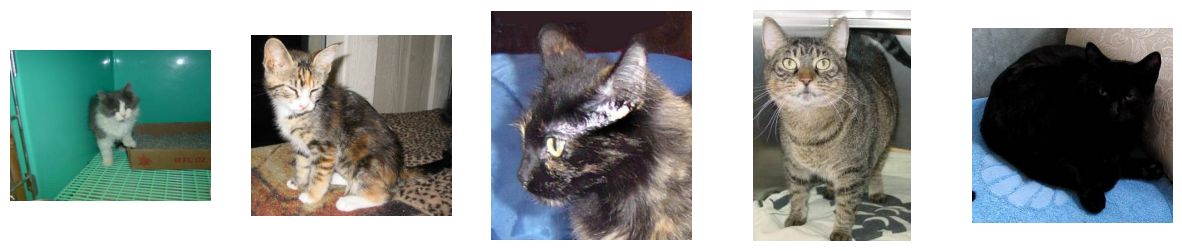



Kelas: dogs


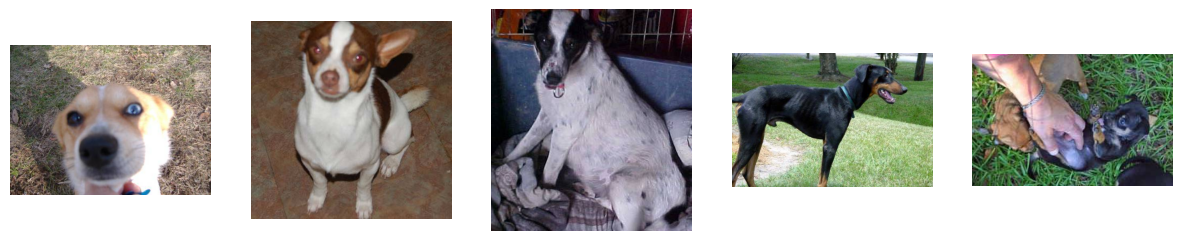

In [19]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
animal = {}

# Tentukan path sumber train
path = "/root/dataset_split/train"
path_sub = path
for i in os.listdir(path_sub):
    animal[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = path

def show_images_grid(data_dict, base_path, num_images=5, img_size=(3, 3)):
    for kelas, file_list in data_dict.items():
        print(f"Kelas: {kelas}")
        selected_files = random.sample(file_list, min(num_images, len(file_list)))

        fig, axes = plt.subplots(1, len(selected_files), figsize=(img_size[0]*len(selected_files), img_size[1]))

        if len(selected_files) == 1:
            axes = [axes]  # supaya iterable kalau cuma 1 gambar

        for ax, file in zip(axes, selected_files):
            img_path = os.path.join(base_path, kelas, file)
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.axis('off')  # matikan axis
        plt.show()
        print("\n")

# Panggil fungsi dengan dictionary gambar, path folder dan jumlah gambar per kelas
show_images_grid(animal, path, num_images=5)

## Modelling

callback

In [20]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy') > 0.93 and logs.get('val_accuracy') > 0.93):
      print('\n Accuracy sudah mencapai > 93%')
      self.model.stop_training = True

callbacks = myCallback()

In [21]:
!pip install keras

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPool2D
from tensorflow.keras.optimizers import Adam

In [23]:
tf.random.set_seed(42)

model = Sequential()

model.add(
    Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=(224, 224, 3))
)
model.add(Conv2D(20, (3, 3), activation="relu"))
model.add(MaxPool2D((2, 2), padding="valid"))

model.add(Conv2D(50, (3, 3), activation="relu"))
model.add(Conv2D(50, (3, 3), activation="relu"))
model.add(MaxPool2D((2, 2)))

model.add(Flatten())
model.add(Dense(3, activation="softmax"))  # number of neurons have to match number of class

# Compile the model
model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"],
)

# Melatih model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator  # Menggunakan test_generator sebagai validasi
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 117s 509ms/step - accuracy: 0.4157 - loss: 1.2262 - val_accuracy: 0.4694 - val_loss: 1.0153
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 103s 486ms/step - accuracy: 0.5531 - loss: 0.8949 - val_accuracy: 0.6028 - val_loss: 0.7728
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 141s 482ms/step - accuracy: 0.6399 - loss: 0.7494 - val_accuracy: 0.6250 - val_loss: 0.7345
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 101s 476ms/step - accuracy: 0.6292 - loss: 0.7584 - val_accuracy: 0.6722 - val_loss: 0.6012
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 103s 490ms/step - accuracy: 0.6935 - loss: 0.6510 - val_accuracy: 0.7222 - val_loss: 0.5553
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 482ms/step - accuracy: 0.7061 - loss: 0.6006 - val_accuracy: 0.7500 - val_loss: 0.4916
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 101s 481ms/step - accuracy: 0.7172 - loss: 0.6030 - val_accuracy: 0.7611 - val_loss: 0.5167
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 100s 476ms/step - accuracy: 0.6970 -

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 20)   │         5,780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 20)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 50)   │         9,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 50)   │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 140450)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │       421,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,889 (5.26 MB)

 Trainable params: 459,629 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 919,260 (3.51 MB)

## Evaluasi dan Visualisasi

In [25]:
import matplotlib.pyplot as plt

def display_training_curves(training, test, title, subplot):
    if subplot % 10 == 1:  # Set up the subplots on the first call
        plt.subplots(figsize=(10, 10), facecolor='#F0F0F0')
        plt.tight_layout()

    ax = plt.subplot(subplot)
    ax.set_facecolor('#F8F8F8')

    # Plot data pelatihan dan pengujian
    ax.plot(training, label='train')
    ax.plot(test, label='test')

    # Set judul dan label
    ax.set_title('Model ' + title)
    ax.set_ylabel(title)
    ax.set_xlabel('Epoch')

    # Menambahkan legenda
    ax.legend()

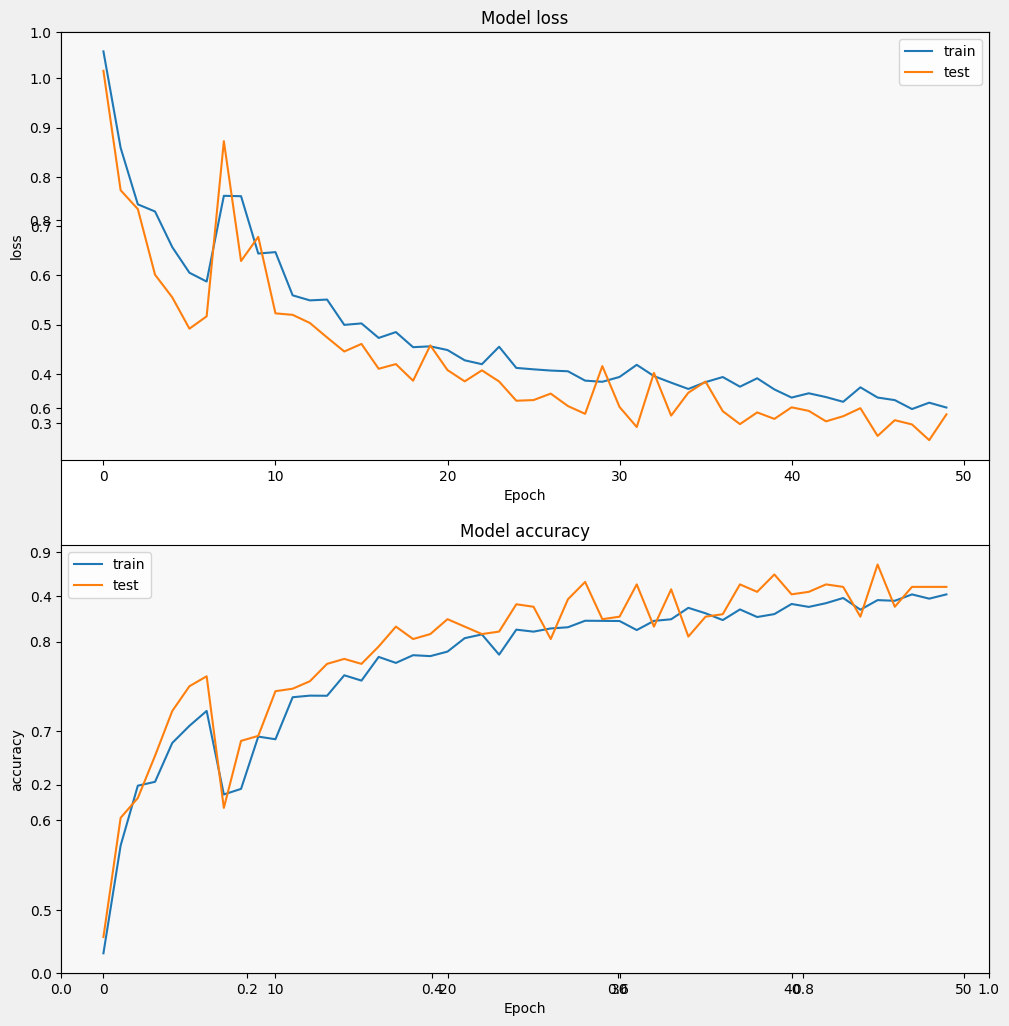

In [26]:
# Display training curves
display_training_curves(
    history.history['loss'],
    history.history['val_loss'],
    'loss', 211
)

display_training_curves(
    history.history['accuracy'],
    history.history['val_accuracy'],
    'accuracy', 212
)


In [27]:
!pip install tensorflow
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [28]:
model.evaluate(test_generator)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8703 - loss: 0.2953


[0.31757989525794983, 0.8611111044883728]

In [29]:
predictions = model.predict(test_generator)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step 
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


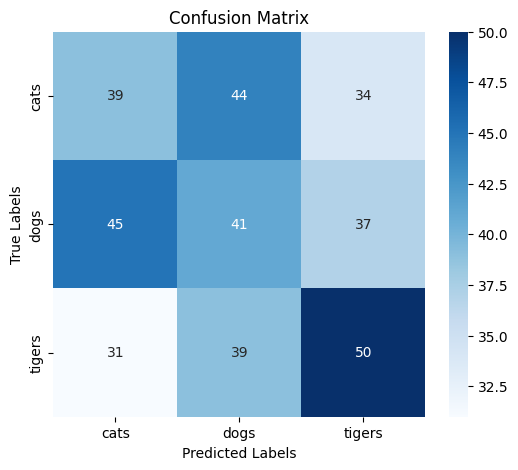

In [30]:
!pip install tensorflow
# 1. Melakukan prediksi
predictions = model.predict(test_generator)

# 2. Konversi ke kelas prediksi
y_pred_class = np.argmax(predictions, axis=1)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False  # Freeze layer pretrained

num_classes = len(train_generator.class_indices)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),  # Ini WAJIB sebelum masuk Dense
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Ambil label asli
y_true_class = test_generator.classes

# 4. Buat confusion matrix
conf_matrix = confusion_matrix(y_true_class, y_pred_class)

# 5. Plot
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


## Konversi Model

Menyimpan Model dalam Format SavedModel

In [31]:
import tensorflow as tf
import numpy as np
import shutil

model = tf.keras.applications.MobileNet()

tf.saved_model.save(model, "saved_model/1")

loaded_model = tf.saved_model.load("saved_model/1")

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [32]:
import shutil

shutil.make_archive('/content/saved_model', 'zip', '/content/saved_model')

'/content/saved_model.zip'

Menyimpan Model ke dalam Format TensorFlow Lite

In [33]:
def save_model_as_tflite(model, filename='model.tflite', folder='tflite'):
    # Buat folder jika belum ada
    if not os.path.exists(folder):
        os.makedirs(folder)

    # Konversi model keras ke TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()

    # Simpan file tflite
    file_path = os.path.join(folder, filename)
    with open(file_path, 'wb') as f:
        f.write(tflite_model)

save_model_as_tflite(model)

Saved artifact at '/tmp/tmpr3sm4s45'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_283')
Output Type:
  TensorSpec(shape=(None, 1000), dtype=tf.float32, name=None)
Captures:
  139095472781840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095473996432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095473997008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095472782608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095473996048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095473998352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095473998736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095473999120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095473998928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139095473995856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1390954

In [34]:
import shutil

# Contoh: menyimpan folder saved_model
shutil.make_archive('/content/tflite', 'zip', '/content/tflite')

'/content/tflite.zip'

Menyimpan Model ke dalam Format TensorFlow.js

In [35]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.34.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [36]:
!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model saved_model/1/ model_tfjs

2025-06-05 04:00:41.146094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749096041.179037   26707 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749096041.188933   26707 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-06-05 04:00:46.495335: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1749096046.495507   26707 gpu_device.cc:2022] Created device /job:localhost/replica:0/task

In [37]:
import shutil

shutil.make_archive('/content/model_tfjs', 'zip', '/content/model_tfjs')

'/content/model_tfjs.zip'

## Inference (Optional)

In [38]:
from tensorflow.keras.utils import get_file, load_img, img_to_array

In [39]:
infer = loaded_model.signatures["serving_default"]

img_path = get_file("kucing.jpg",
    "https://images.ctfassets.net/82d3r48zq721/5nu9ucFJsFxIyP3Gtn0k3R/1e9540898865229d64b2eae22a5bb286/White-kitten-wrapped-in-blankets_resized.jpg?w=1000&h=667&q=50&fm=webp")

img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = tf.keras.applications.mobilenet.preprocess_input(x[tf.newaxis, ...])

hasil = infer(tf.constant(x))

54194/54194 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [40]:
from tensorflow.keras.applications.mobilenet import preprocess_input, decode_predictions
# 4. Tampilkan nama output
print("Nama output:", hasil.keys())  # biasanya 'output_0'

# 5. Ambil nilai output dan decode prediksi
prediksi = hasil['output_0'].numpy()
top_3 = decode_predictions(prediksi, top=3)[0]

# 6. Tampilkan hasil prediksi
for kode, nama, skor in top_3:
    print(f"{nama}: {skor:.4f}")

Nama output: dict_keys(['output_0'])
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Persian_cat: 0.4951
bath_towel: 0.1120
Pomeranian: 0.0872
